In [4]:
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import os

In [6]:
csv_path = './sales_data/retail_sales.csv'

if os.path.exists(csv_path):
    data = pd.read_csv(csv_path)
    print("Data has been sucessfully loaded")
else:
    raise ValueError("No data is loaded")



Data has been sucessfully loaded


In [ ]:
data.head(10) # gives 10 rows from the top

,Date,Product,Category,Quantity,UnitPrice,Sales,Profit
0,2024-01-01,Headphones,Electronics,9,962,8658.0,1718.59
1,2024-01-01,Smartphone,Electronics,28,1051,29428.0,7895.22
2,2024-01-01,Laptop,Electronics,16,248,3968.0,1362.68
3,2024-01-01,Tablet,Electronics,45,949,42705.0,12480.00
4,2024-01-01,Jeans,Clothing,33,24,792.0,159.67
5,2024-01-01,T-Shirt,Clothing,32,50,1600.0,528.36
6,2024-01-01,Jacket,Clothing,47,80,3760.0,1136.07
7,2024-01-01,Sneakers,Clothing,34,58,1972.0,278.75
8,2024-01-01,Desk,Furniture,10,71,710.0,69.03
9,2024-01-01,Chair,Furniture,52,101,5252.0,1315.89


In [ ]:
data.info() # provides column information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       120 non-null    object 
 1   Product    120 non-null    object 
 2   Category   120 non-null    object 
 3   Quantity   120 non-null    int64  
 4   UnitPrice  120 non-null    int64  
 5   Sales      120 non-null    float64
 6   Profit     120 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 6.7+ KB


In [ ]:
data.describe() # statistics of the csv

,Quantity,UnitPrice,Sales,Profit
count,120.000000,120.000000,120.000000,120.000000
mean,32.666667,176.658333,5971.066667,1364.993500
std,16.715279,274.980534,11153.540414,2942.009853
min,5.000000,11.000000,138.000000,19.410000
25%,18.750000,39.750000,903.000000,180.242500
50%,32.000000,71.500000,1881.500000,415.775000
75%,48.000000,112.000000,4059.000000,933.430000
max,59.000000,1051.000000,56994.000000,19514.350000


PyPlot Approach

In [14]:
monthly_sale = data.groupby('Date')['Sales'].sum().sort_index() # group the data by sales, add all the sales, then sort
monthly_profit = data.groupby('Date')['Profit'].sum().sort_index()

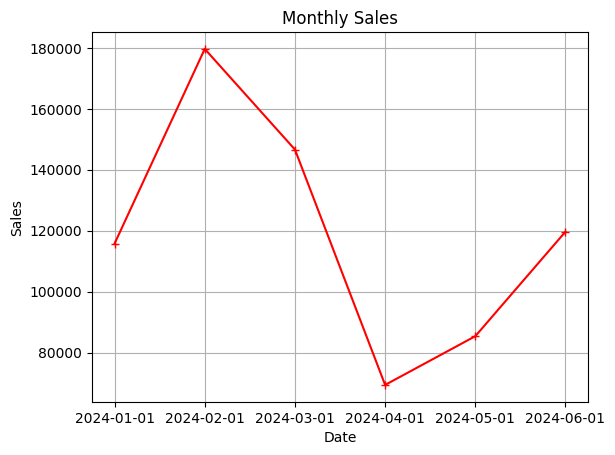

In [16]:
plt.figure()
plt.plot(monthly_sale.index, monthly_sale, marker = '+', color ='r') # google matplotlib for marker and colors
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Monthly Sales')
plt.grid(True)
plt.show()

Object-Oriented Approach

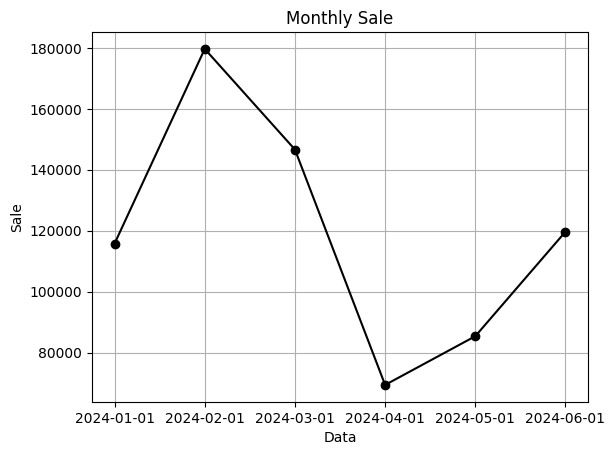

In [ ]:
fig, ax = plt.subplots()
ax.plot(monthly_sale.index, monthly_sale, marker = 'o', color = 'k')
ax.set_xlabel('Data')
ax.set_ylabel('Sale')
ax.set_title('Monthly Sale')
ax.grid(True)
# fig.show() # to print every figure


Bar plot

In [23]:
sales_by_cat = data.groupby('Category')['Sales'].sum().sort_values(ascending=False) # largest to smallest
print(sales_by_cat)

Category
Electronics    541941.0
Furniture       50938.0
Clothing        47216.0
Groceries       43589.0
Books           32844.0
Name: Sales, dtype: float64


/var/folders/k2/09c8j5sd6bbf32rnpwj0kk600000gn/T/ipykernel_72910/3997028678.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


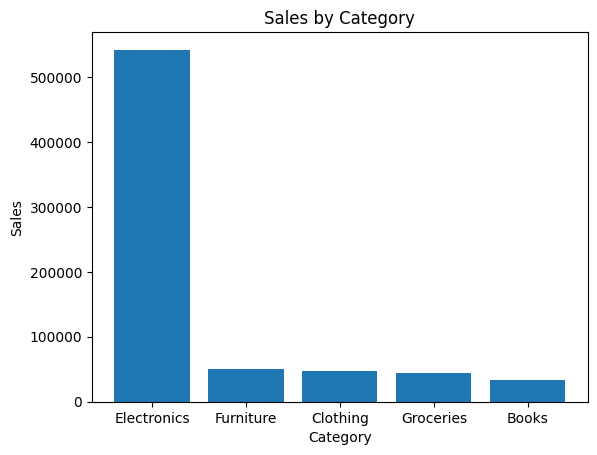

In [25]:
fig, ax = plt.subplots()
ax.bar(sales_by_cat.index, sales_by_cat)
ax.set_xlabel('Category')
ax.set_ylabel('Sales')
ax.set_title('Sales by Category')
fig.show()


       Category     Product     Sales    Profit
0         Books    Magazine    8683.0   2263.08
1         Books    Notebook    7611.0   2105.58
2         Books       Novel   10752.0   1912.89
3         Books    Textbook    5798.0   1279.82
4      Clothing      Jacket   17452.0   4356.54
5      Clothing       Jeans    8234.0   1941.06
6      Clothing    Sneakers    9126.0   1660.62
7      Clothing     T-Shirt   12404.0   2988.64
8   Electronics  Headphones  164671.0  45342.60
9   Electronics      Laptop   83260.0  20934.92
10  Electronics  Smartphone  144611.0  23353.28
11  Electronics      Tablet  149399.0  34791.03
12    Furniture   Bookshelf   12480.0   3547.43
13    Furniture       Chair   14249.0   2953.40
14    Furniture        Desk    8564.0   1619.41
15    Furniture        Sofa   15645.0   4009.54
16    Groceries      Apples   11837.0   3274.65
17    Groceries       Bread    9709.0   1386.67
18    Groceries        Eggs    9379.0   1490.25
19    Groceries        Milk   12664.0   

/var/folders/k2/09c8j5sd6bbf32rnpwj0kk600000gn/T/ipykernel_72910/3725550215.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


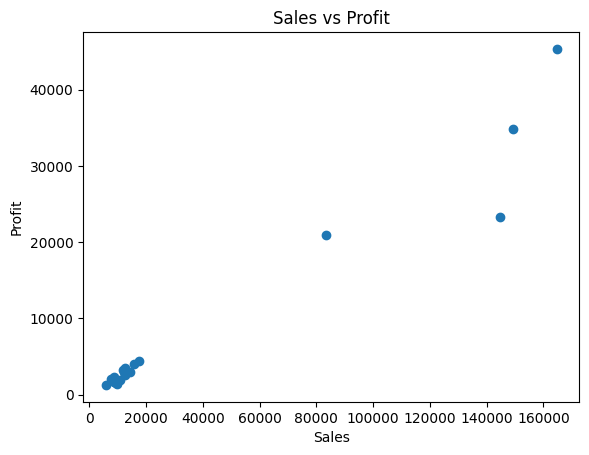

In [ ]:
product = data.groupby(['Category', 'Product'])[['Sales', 'Profit']].sum().reset_index() # each dot is showing the profits of a specific product and its category

print(product)

fig, ax = plt.subplots()
ax.scatter(product['Sales'],product['Profit'])
ax.set_xlabel('Sales')
ax.set_ylabel('Profit')
ax.set_title('Sales vs Profit')
fig.show()


/var/folders/k2/09c8j5sd6bbf32rnpwj0kk600000gn/T/ipykernel_72910/563761120.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


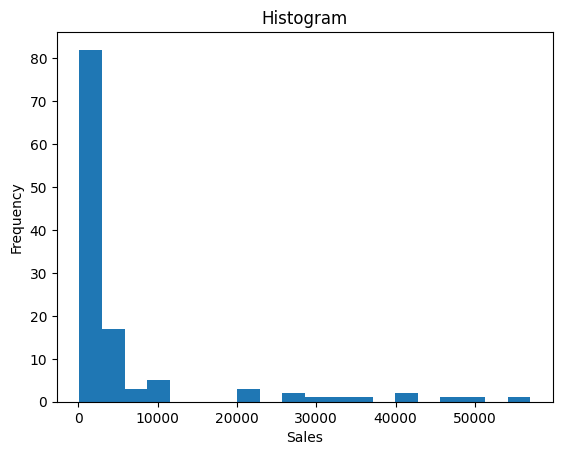

In [39]:
fig, ax = plt.subplots()
ax.hist(data['Sales'], bins=20) # usually bin size is from 5 - 20, depends on your data and how you want to visualize it
ax.set_xlabel('Sales')
ax.set_ylabel('Frequency')
ax.set_title('Histogram')
fig.show()

/var/folders/k2/09c8j5sd6bbf32rnpwj0kk600000gn/T/ipykernel_72910/4241714245.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


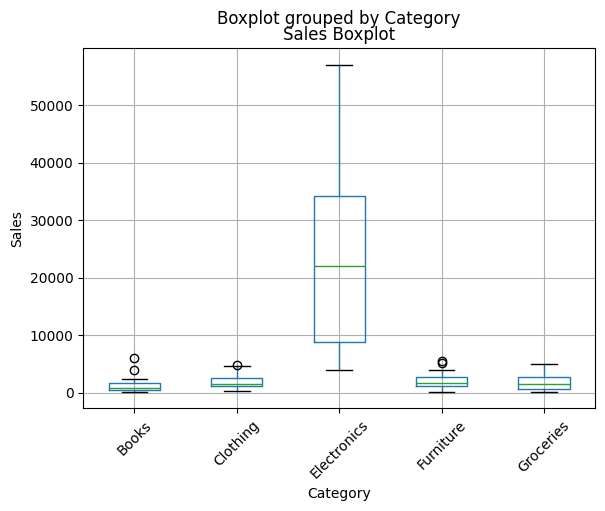

In [44]:
fig, ax = plt.subplots()
data.boxplot(column = 'Sales', by = 'Category', rot = 45, ax = ax) # rot = rotation
ax.set_ylabel('Sales')
ax.set_title('Sales Boxplot')
fig.show()


to save

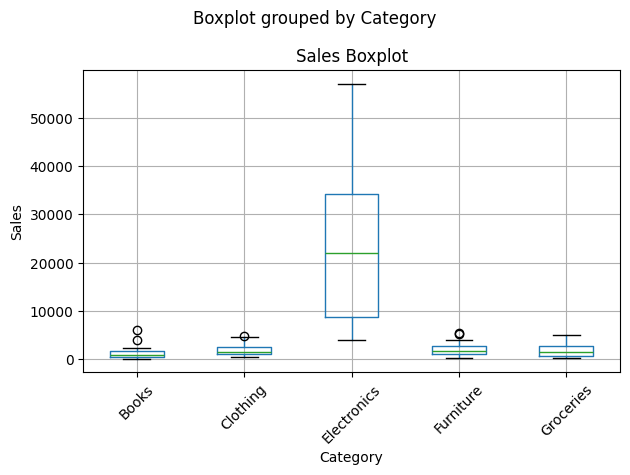

In [47]:
fig, ax = plt.subplots()
data.boxplot(column = 'Sales', by = 'Category', rot = 45, ax = ax) # rot = rotation
ax.set_ylabel('Sales')
ax.set_title('Sales Boxplot')

fig.tight_layout() # this way the layout has no white space and also isnt cut off
fig.savefig('monthly_sales.png')
